Computing MSE curves for different N values...
  Computing N=1...
    σ^o=0.1000, MSE_min=0.3697
  Computing N=2...
    σ^o=0.2489, MSE_min=0.3270
  Computing N=10...
    σ^o=0.6930, MSE_min=0.1808
  Computing N=31...
    σ^o=1.0073, MSE_min=0.1029
  Computing N=61...
    σ^o=1.2097, MSE_min=0.0709

=== Optimal Parameters Summary ===
N=  1: σ^o=0.1000, MSE_min=0.3697, Normalized MSE=0.3697 (no marker)
N=  2: σ^o=0.2489, MSE_min=0.3270, Normalized MSE=0.3270 marked at (0.249, 0.3270)
N= 10: σ^o=0.6930, MSE_min=0.1808, Normalized MSE=0.1808 marked at (0.693, 0.1808)
N= 31: σ^o=1.0073, MSE_min=0.1029, Normalized MSE=0.1029 marked at (1.007, 0.1029)
N= 61: σ^o=1.2097, MSE_min=0.0709, Normalized MSE=0.0709 marked at (1.210, 0.0709)


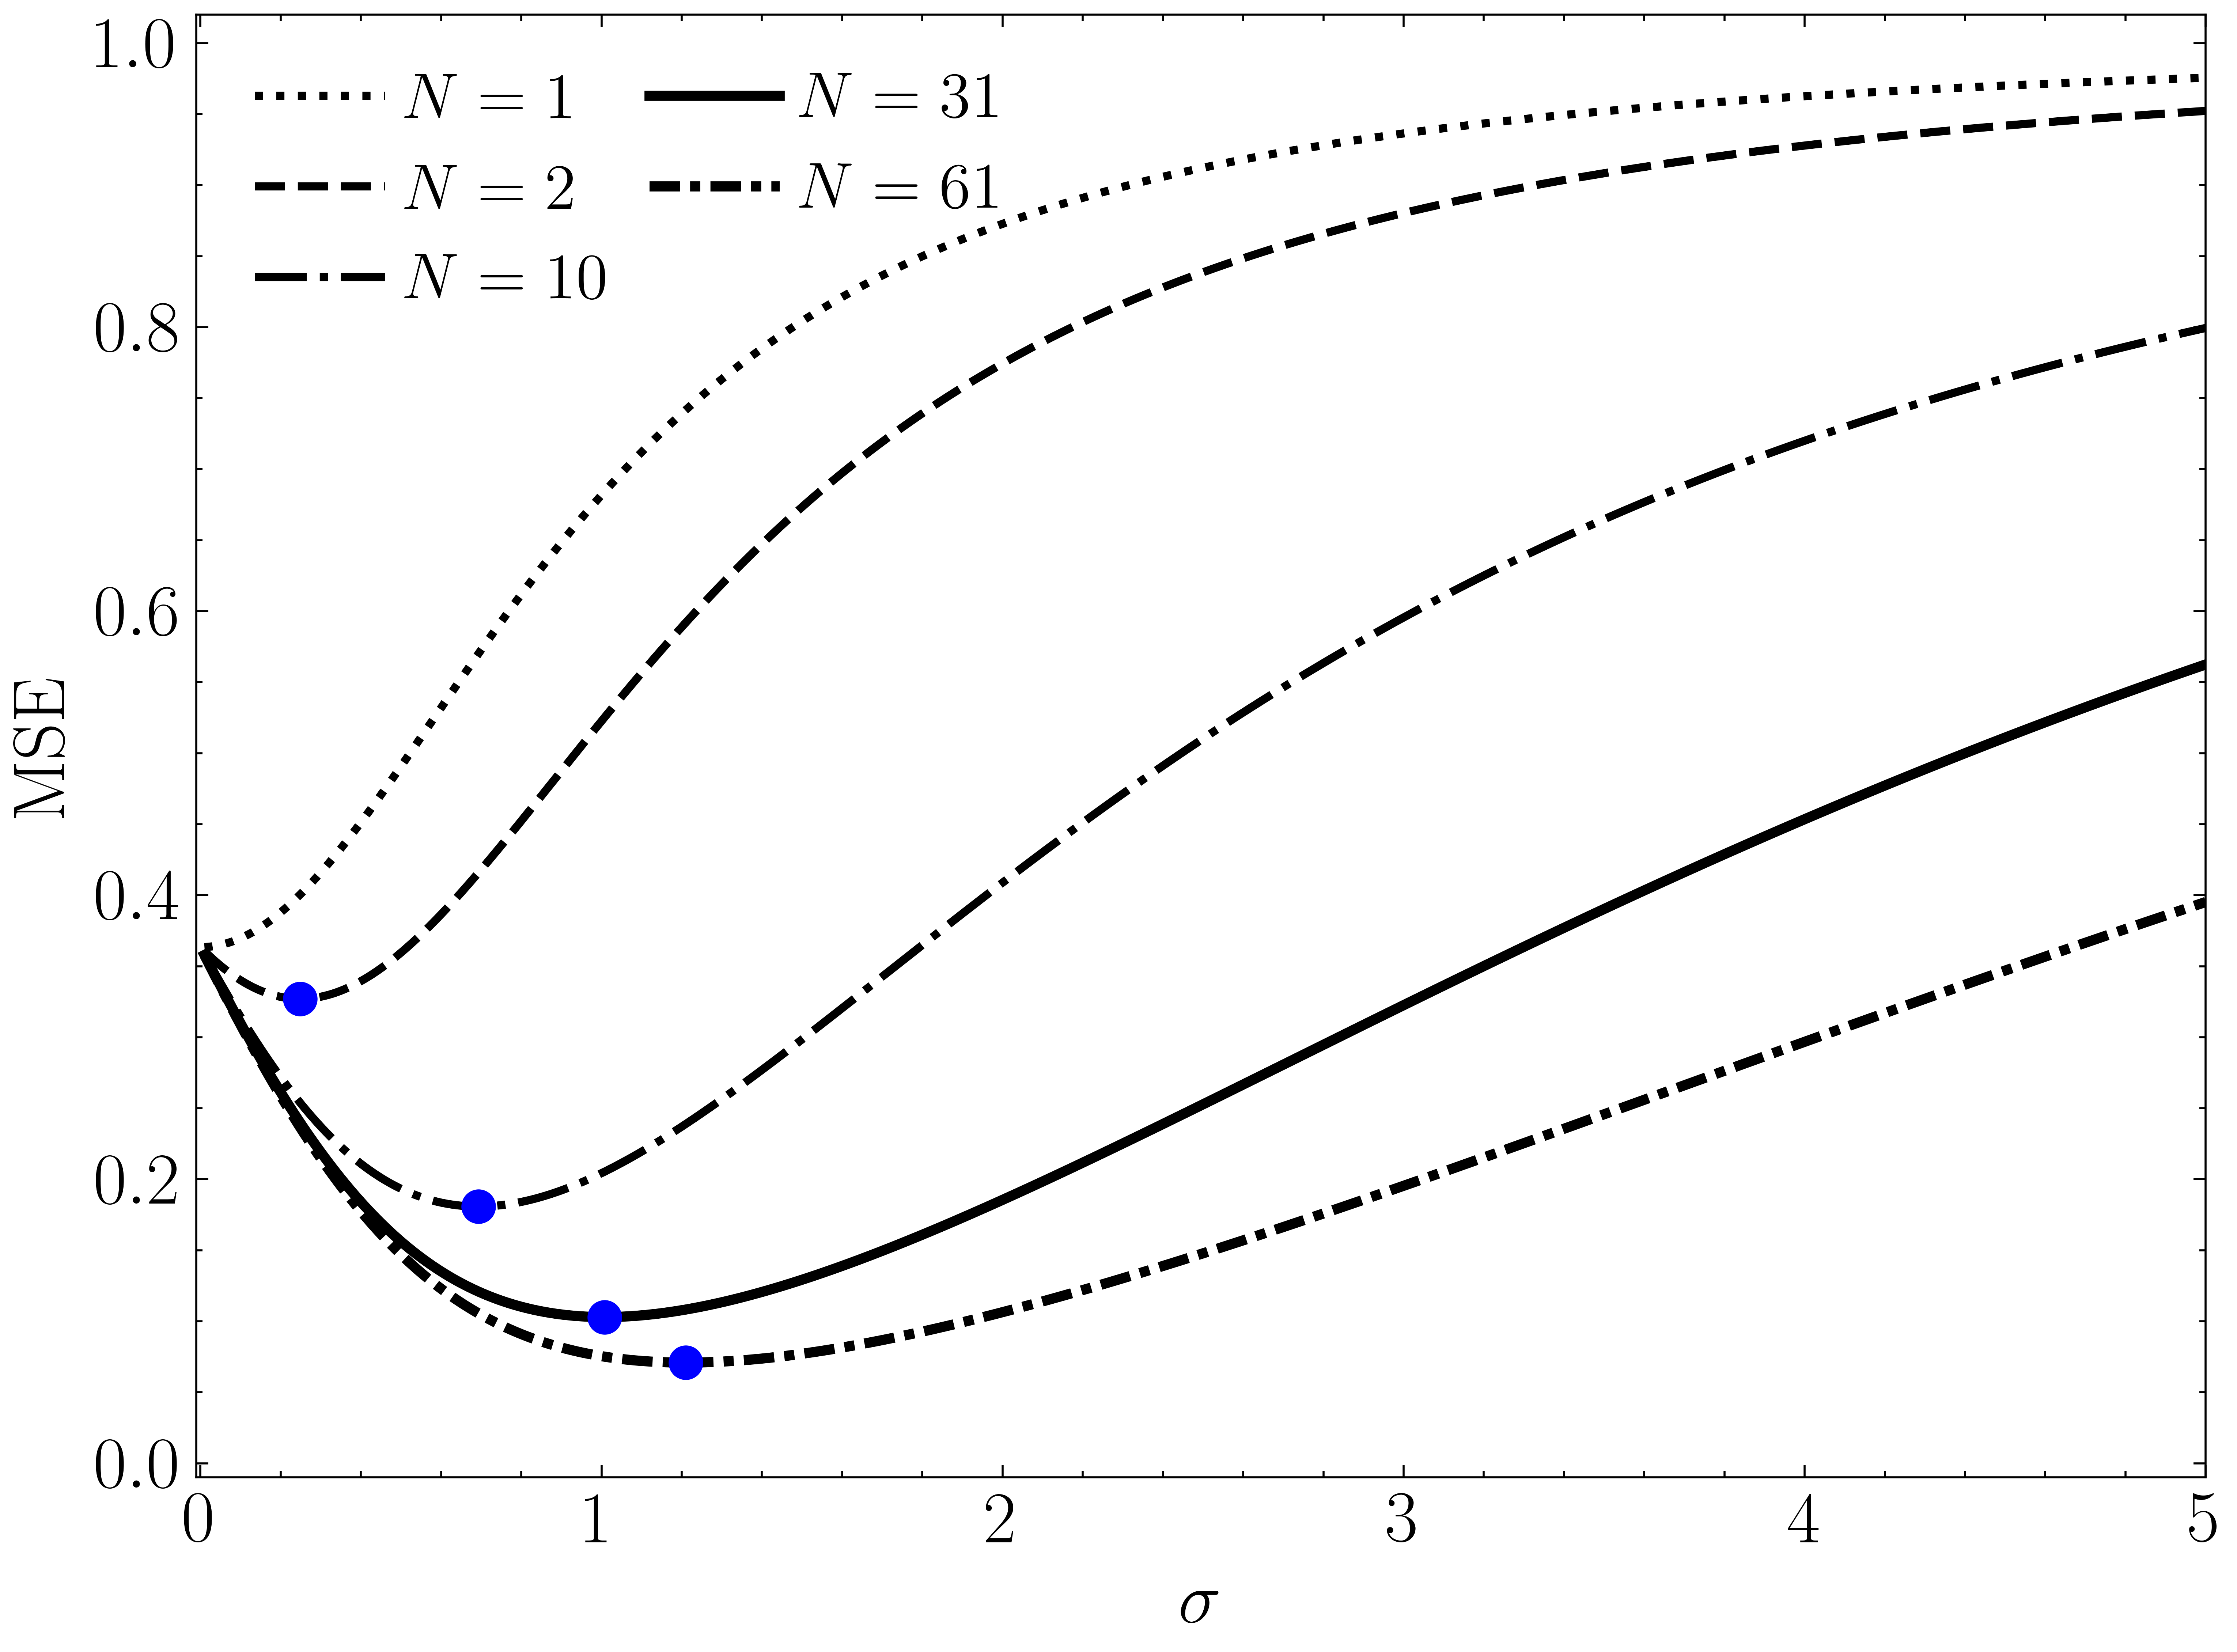

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import ScalarFormatter
from scipy.special import erf
from scipy.integrate import quad
from scipy.optimize import minimize_scalar
import colorsys
import scienceplots
# 设置绘图风格
plt.style.use(['science', 'ieee'])
plt.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['figure.dpi'] = 800
mpl.rcParams['axes.unicode_minus'] = False
mpl.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'mathtext.fontset': 'stix',
    'font.size': 15,
    'axes.labelsize': 15,
    'legend.fontsize': 13,
})

def lighten_color(color, amount=0.7):
    """
    Lightens the given color by mixing with white
    amount=0 returns white, amount=1 returns original color
    """
    import matplotlib.colors as mc
    import colorsys
    try:
        c = mc.cnames[color]
    except:
        c = color
    c = colorsys.rgb_to_hls(*mc.to_rgb(c))
    return colorsys.hls_to_rgb(c[0], 1 - amount * (1 - c[1]), c[2])


class StocksExactTheory:
    """
    Stocks (2001) PRE的精确MSE公式 - 正确实现
    """
    def __init__(self, sigma_x=1.0, N=31):
        self.sigma_x = sigma_x
        self.N = N
    
    def smooth_function(self, x, sigma):
        """
        平滑函数 h̄(x,σ) = erf(x/(σ√2))
        """
        return erf(x / (sigma * np.sqrt(2)))
    
    def gaussian_pdf(self, x):
        """
        高斯PDF
        """
        return np.exp(-x**2 / (2*self.sigma_x**2)) / np.sqrt(2*np.pi*self.sigma_x**2)
    
    def compute_p_numerical(self, sigma):
        """
        数值计算 p(σ) = E[x·h̄(x,σ)]
        """
        def integrand(x):
            return x * self.smooth_function(x, sigma) * self.gaussian_pdf(x)
        
        result, _ = quad(integrand, -10*self.sigma_x, 10*self.sigma_x)
        return result
    
    def compute_psi_numerical(self, sigma):
        """
        数值计算 ψ(σ) = E[h̄²(x,σ)]
        """
        def integrand(x):
            h_bar = self.smooth_function(x, sigma)
            return h_bar**2 * self.gaussian_pdf(x)
        
        result, _ = quad(integrand, -10*self.sigma_x, 10*self.sigma_x)
        return result
    
    def mse_stocks_numerical(self, sigma):
        """
        Stocks精确公式（数值计算）
        MSE = σ_x² - N·p²/(1 + (N-1)ψ)
        """
        p = self.compute_p_numerical(sigma)
        psi = self.compute_psi_numerical(sigma)
        
        denominator = 1 + (self.N - 1) * psi
        mse = self.sigma_x**2 - (self.N * p**2) / denominator
        
        return mse
    
    def find_optimal_sigma(self):
        """
        找最优σ
        """
        result = minimize_scalar(
            self.mse_stocks_numerical,
            bounds=(0.1*self.sigma_x, 3*self.sigma_x),
            method='bounded'
        )
        return result.x, result.fun


def plot_mse_vs_sigma_multiple_N():
    """
    绘制不同N值下的MSE vs σ曲线
    """
    sigma_x = 1.0
    N_values = [1, 2, 10, 31, 61]
    
    # 噪声范围
    sigma_range = np.linspace(0.01, 5, 500) * sigma_x
    
    # 定义5种线型
    line_styles = [
        ':',      # 实线 (N=1)
        '--',     # 虚线 (N=2)
        '-.',     # 点划线 (N=10)
        '-',      # 点线 (N=31)
        (0, (3, 1, 1, 1))  # 密集点划线 (N=61)
    ]
    
    # 定义线宽
    line_widths = [2.0, 2.0, 2.0, 2.5, 2.5]
    
    # 创建图形
    fig, ax = plt.subplots(figsize=(8, 6))
    
    print("Computing MSE curves for different N values...")
    
    optimal_points = []
    
    for idx, N in enumerate(N_values):
        print(f"  Computing N={N}...")
        
        # 创建理论模型
        theory = StocksExactTheory(sigma_x=sigma_x, N=N)
        
        # 计算MSE曲线
        mse_array = []
        for sigma in sigma_range:
            mse = theory.mse_stocks_numerical(sigma)
            mse_array.append(mse)
        mse_array = np.array(mse_array)
        
        # 找最优点
        sigma_opt, mse_opt = theory.find_optimal_sigma()
        optimal_points.append((sigma_opt, mse_opt))
        
        # 绘制曲线（全部黑色）
        ax.plot(sigma_range/sigma_x, mse_array, 
                color='black',
                linestyle=line_styles[idx],
                linewidth=line_widths[idx],
                label=f'$N={N}$',
                zorder=10-idx)
        
        # 标记最优点（N=1除外）
        if N > 1:
            ax.plot(sigma_opt/sigma_x, mse_opt, 
                    'o', 
                    color='blue',
                    markersize=7,
                    markerfacecolor='blue',
                    markeredgewidth=1.5,
                    zorder=15-idx)
        
        print(f"    σ^o={sigma_opt:.4f}, MSE_min={mse_opt:.4f}")
    
    # 设置坐标轴
    ax.set_xlabel(r'$\sigma$',fontsize = 18)
    ax.set_ylabel('MSE',fontsize = 18)
    ax.tick_params(axis='both', labelsize=18) 
    # 图例
    ax.legend(
        loc='upper left',
    #bbox_to_anchor=(0.7, 1.0),
        ncol=2, 
        fontsize = 16,    
        columnspacing=0.6,
        handletextpad=0.3)
    
    # 网格
    #ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.5)
    
    # 设置x轴范围
    ax.set_xlim([-0.01, 5])
    ax.set_ylim([-0.01, 1.02])
    # 设置y轴范围（根据数据自动调整，也可以手动设置）
    # ax.set_ylim([0, 1.0])
    
    plt.tight_layout()
    
    # 保存
    plt.savefig('D:/IEEE 2025 Adaptive weighted SSR/Figtheore.eps', format='eps', dpi=800)
    
    print("\n=== Optimal Parameters Summary ===")
    for idx, N in enumerate(N_values):
        sigma_opt, mse_opt = optimal_points[idx]
        marker_info = "(no marker)" if N == 1 else f"marked at ({sigma_opt/sigma_x:.3f}, {mse_opt:.4f})"
        print(f"N={N:3d}: σ^o={sigma_opt:.4f}, MSE_min={mse_opt:.4f}, "
              f"Normalized MSE={mse_opt/sigma_x**2:.4f} {marker_info}")
    
    plt.show()
    
    return optimal_points


optimal_points = plot_mse_vs_sigma_multiple_N()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erf
from scipy.stats import norm
from scipy.integrate import quad
from scipy.optimize import minimize_scalar

class QuantizerComparison:
    """
    对比{0,1}和{-1,+1}两种量化器
    """
    def __init__(self, sigma_x=1.0, N=31):
        self.sigma_x = sigma_x
        self.N = N
    
    def gaussian_pdf(self, x):
        return np.exp(-x**2 / (2*self.sigma_x**2)) / np.sqrt(2*np.pi*self.sigma_x**2)
    
    # ============ {-1, +1} 量化器（您的设置）============
    def smooth_bipolar(self, x, sigma):
        """双极性量化器的期望响应: erf(x/(σ√2))"""
        return erf(x / (sigma * np.sqrt(2)))
    
    def compute_p_bipolar(self, sigma):
        """p(σ) for {-1,+1} quantizer"""
        def integrand(x):
            return x * self.smooth_bipolar(x, sigma) * self.gaussian_pdf(x)
        result, _ = quad(integrand, -10*self.sigma_x, 10*self.sigma_x)
        return result
    
    def compute_psi_bipolar(self, sigma):
        """ψ(σ) for {-1,+1} quantizer"""
        def integrand(x):
            h_bar = self.smooth_bipolar(x, sigma)
            return h_bar**2 * self.gaussian_pdf(x)
        result, _ = quad(integrand, -10*self.sigma_x, 10*self.sigma_x)
        return result
    
    def mse_bipolar(self, sigma):
        """MSE for {-1,+1} quantizer"""
        p = self.compute_p_bipolar(sigma)
        psi = self.compute_psi_bipolar(sigma)
        mse = self.sigma_x**2 - (self.N * p**2) / (1 + (self.N - 1) * psi)
        return mse
    
    # ============ {0, 1} 量化器（Mark的设置）============
    def smooth_unipolar(self, x, sigma):
        """单极性量化器的期望响应: Φ(x/σ)"""
        return norm.cdf(x / sigma)
    
    def compute_p_unipolar(self, sigma):
        """p(σ) for {0,1} quantizer"""
        def integrand(x):
            return x * self.smooth_unipolar(x, sigma) * self.gaussian_pdf(x)
        result, _ = quad(integrand, -10*self.sigma_x, 10*self.sigma_x)
        return result
    
    def compute_psi_unipolar(self, sigma):
        """ψ(σ) for {0,1} quantizer"""
        def integrand(x):
            h_bar = self.smooth_unipolar(x, sigma)
            return h_bar**2 * self.gaussian_pdf(x)
        result, _ = quad(integrand, -10*self.sigma_x, 10*self.sigma_x)
        return result
    
    def mse_unipolar(self, sigma):
        """MSE for {0,1} quantizer"""
        p = self.compute_p_unipolar(sigma)
        psi = self.compute_psi_unipolar(sigma)
        mse = self.sigma_x**2 - (self.N * p**2) / (1 + (self.N - 1) * psi)
        return mse
    
    # ============ Mark的渐近公式 ============
    def mse_mark_asymptotic(self, sigma):
        """
        Mark (2010)的渐近公式
        注意：这是针对{0,1}量化器推导的
        """
        ratio = sigma / self.sigma_x
        return self.sigma_x**2 * (1 - 2/(np.pi * (1 + 2*ratio**2)))
    
    def find_optimal_bipolar(self):
        """找{-1,+1}量化器的最优点"""
        result = minimize_scalar(
            self.mse_bipolar,
            bounds=(0.1*self.sigma_x, 3*self.sigma_x),
            method='bounded'
        )
        return result.x, result.fun
    
    def find_optimal_unipolar(self):
        """找{0,1}量化器的最优点"""
        result = minimize_scalar(
            self.mse_unipolar,
            bounds=(0.1*self.sigma_x, 3*self.sigma_x),
            method='bounded'
        )
        return result.x, result.fun


def detailed_comparison():
    """
    详细对比两种量化器
    """
    sigma_x = 1.0
    
    print("="*80)
    print("COMPARISON: {-1,+1} vs {0,1} Quantizers")
    print("="*80)
    
    # N=31的对比
    print("\n--- N = 31 ---")
    comp_31 = QuantizerComparison(sigma_x=sigma_x, N=31)
    
    sigma_opt_bi, mse_opt_bi = comp_31.find_optimal_bipolar()
    print(f"\n{-1,+1} Quantizer (Your Setup):")
    print(f"  Optimal σ:  {sigma_opt_bi:.4f}")
    print(f"  Minimum MSE: {mse_opt_bi:.4f}")
    print(f"  Your Experiment: 0.103 ± 0.006")
    print(f"  Gap: {abs(mse_opt_bi - 0.103)/0.103*100:.2f}%")
    
    sigma_opt_uni, mse_opt_uni = comp_31.find_optimal_unipolar()
    print(f"\n{{0,1}} Quantizer (Mark's Setup):")
    print(f"  Optimal σ:  {sigma_opt_uni:.4f}")
    print(f"  Minimum MSE: {mse_opt_uni:.4f}")
    
    mse_mark_31 = comp_31.mse_mark_asymptotic(sigma_opt_uni)
    print(f"\nMark's Asymptotic Formula (for {{0,1}}):")
    print(f"  MSE: {mse_mark_31:.4f}")
    
    # N=61的对比
    print("\n" + "="*80)
    print("--- N = 61 ---")
    comp_61 = QuantizerComparison(sigma_x=sigma_x, N=61)
    
    sigma_opt_bi_61, mse_opt_bi_61 = comp_61.find_optimal_bipolar()
    print(f"\n{{-1,+1}} Quantizer (Your Setup):")
    print(f"  Optimal σ:  {sigma_opt_bi_61:.4f}")
    print(f"  Minimum MSE: {mse_opt_bi_61:.4f}")
    print(f"  Your Experiment: 0.054 ± 0.003")
    print(f"  Gap: {abs(mse_opt_bi_61 - 0.054)/0.054*100:.2f}%")
    
    sigma_opt_uni_61, mse_opt_uni_61 = comp_61.find_optimal_unipolar()
    print(f"\n{{0,1}} Quantizer (Mark's Setup):")
    print(f"  Optimal σ:  {sigma_opt_uni_61:.4f}")
    print(f"  Minimum MSE: {mse_opt_uni_61:.4f}")
    
    # 关键结论
    print("\n" + "="*80)
    print("KEY FINDINGS:")
    print("="*80)
    print(f"\n1. DIFFERENT QUANTIZERS → DIFFERENT MSE:")
    print(f"   N=31: {{-1,+1}} MSE = {mse_opt_bi:.4f}  vs  {{0,1}} MSE = {mse_opt_uni:.4f}")
    print(f"   N=61: {{-1,+1}} MSE = {mse_opt_bi_61:.4f}  vs  {{0,1}} MSE = {mse_opt_uni_61:.4f}")
    print(f"\n2. Mark's formula is for {{0,1}} quantizers, NOT {{-1,+1}}!")
    print(f"   Your experiments use {{-1,+1}}, so direct comparison is invalid.")
    print(f"\n3. For fair comparison, use Stocks' formula with correct h̄(x,σ):")
    print(f"   {{-1,+1}}: h̄(x,σ) = erf(x/(σ√2))")
    print(f"   {{0,1}}:   h̄(x,σ) = Φ(x/σ)")
    
    # 绘图对比
    plot_both_quantizers(comp_31, comp_61)
    
    return comp_31, comp_61


def plot_both_quantizers(comp_31, comp_61):
    """
    绘制两种量化器的MSE曲线对比
    """
    sigma_range = np.linspace(0.3, 2.5, 100)
    
    # 计算MSE曲线
    mse_bi_31 = [comp_31.mse_bipolar(s) for s in sigma_range]
    mse_uni_31 = [comp_31.mse_unipolar(s) for s in sigma_range]
    
    mse_bi_61 = [comp_61.mse_bipolar(s) for s in sigma_range]
    mse_uni_61 = [comp_61.mse_unipolar(s) for s in sigma_range]
    
    # 最优点
    sigma_bi_31, mse_opt_bi_31 = comp_31.find_optimal_bipolar()
    sigma_uni_31, mse_opt_uni_31 = comp_31.find_optimal_unipolar()
    sigma_bi_61, mse_opt_bi_61 = comp_61.find_optimal_bipolar()
    sigma_uni_61, mse_opt_uni_61 = comp_61.find_optimal_unipolar()
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # 子图1：N=31
    ax1 = axes[0]
    ax1.plot(sigma_range, mse_bi_31, 'b-', linewidth=2.5, label='{-1,+1} Quantizer (Yours)')
    ax1.plot(sigma_range, mse_uni_31, 'r--', linewidth=2.5, label='{0,1} Quantizer (Mark)')
    ax1.plot(sigma_bi_31, mse_opt_bi_31, 'bo', markersize=10, 
             label=f'Your Optimum: {mse_opt_bi_31:.4f}')
    ax1.plot(sigma_uni_31, mse_opt_uni_31, 'ro', markersize=10,
             label=f'Mark Optimum: {mse_opt_uni_31:.4f}')
    
    # 标注您的实验结果
    ax1.axhline(0.103, color='g', linestyle=':', linewidth=2, alpha=0.7,
                label='Your Experiment: 0.103')
    
    ax1.set_xlabel('Noise Scale σ', fontsize=13)
    ax1.set_ylabel('MSE', fontsize=13)
    ax1.set_title('N=31: Different Quantizer Types', fontsize=14)
    ax1.legend(fontsize=9)
    ax1.grid(True, alpha=0.3)
    
    # 子图2：N=61
    ax2 = axes[1]
    ax2.plot(sigma_range, mse_bi_61, 'b-', linewidth=2.5, label='{-1,+1} Quantizer (Yours)')
    ax2.plot(sigma_range, mse_uni_61, 'r--', linewidth=2.5, label='{0,1} Quantizer (Mark)')
    ax2.plot(sigma_bi_61, mse_opt_bi_61, 'bo', markersize=10,
             label=f'Your Optimum: {mse_opt_bi_61:.4f}')
    ax2.plot(sigma_uni_61, mse_opt_uni_61, 'ro', markersize=10,
             label=f'Mark Optimum: {mse_opt_uni_61:.4f}')
    
    # 标注您的实验结果
    ax2.axhline(0.054, color='g', linestyle=':', linewidth=2, alpha=0.7,
                label='Your Experiment: 0.054')
    
    ax2.set_xlabel('Noise Scale σ', fontsize=13)
    ax2.set_ylabel('MSE', fontsize=13)
    ax2.set_title('N=61: Different Quantizer Types', fontsize=14)
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('quantizer_type_comparison.pdf', dpi=300, bbox_inches='tight')
    plt.show()



comp_31, comp_61 = detailed_comparison()